In [28]:
import jax.numpy as jnp
from math import pi
import matplotlib.pyplot as plt
import jax.random as jrandom
from utils_v2 import KalmanFilter
from time import time

In [29]:
sigma_x = 0.01
sigma_t = 0.0001
x_values = jnp.arange(-1, 1, sigma_x)
t_values = jnp.arange(0, 2, sigma_t)
len(x_values)

200

In [30]:
x_0 = jnp.sin(x_values * 2 * pi)

In [31]:
def f_eq(x,t,alpha):
    return jnp.exp(-t)*jnp.sin(x*2*pi)*(-1+4*pi**2*alpha)

In [32]:
def heat_eq(u: jnp.ndarray, alpha: float = 0.05) -> jnp.ndarray:
    beta = alpha * sigma_t / sigma_x**2
    u_1 = u[:-2]
    u_2 = u[1:-1]
    u_3 = u[2:]
    f=f_eq(x_values,t_values,alpha)
    interior = u_2 + beta * (u_1 - 2 * u_2 + u_3) + sigma_t*f[1:-1]
    

    x_1 = jnp.concatenate([u[:1] + f[:1], interior, u[-1:]+f[-1:]])
    return x_1


#heat_eq(x_0)

In [33]:
alpha: float = 0.04
n: int = len(x_0)


beta: float = alpha * sigma_t / sigma_x**2

main: jnp.ndarray = jnp.ones(n) * (1 - 2 * beta)
off: jnp.ndarray = jnp.ones(n - 1) * beta

A: jnp.ndarray = jnp.diag(main) + jnp.diag(off, k=-1) + jnp.diag(off, k=1)
A = A.at[0, :].set(jnp.eye(n)[0])
A = A.at[-1, :].set(jnp.eye(n)[-1])
B = jnp.eye(n)

In [34]:
beta = alpha * sigma_t / sigma_x**2

# Interior diagonals
main_m = jnp.ones(n) * (1 + beta)
main_p = jnp.ones(n) * (1 - beta)
off_m  = jnp.ones(n - 1) * (-beta / 2)
off_p  = jnp.ones(n - 1) * ( beta / 2)

M_minus = jnp.diag(main_m) + jnp.diag(off_m, k=-1) + jnp.diag(off_m, k=1)
M_plus  = jnp.diag(main_p) + jnp.diag(off_p, k=-1) + jnp.diag(off_p, k=1)

# Dirichlet BC: boundary rows → identity
eye_rows = jnp.eye(n)
M_minus = M_minus.at[0, :].set(eye_rows[0])
M_minus = M_minus.at[-1, :].set(eye_rows[-1])
M_plus  = M_plus.at[0, :].set(eye_rows[0])
M_plus  = M_plus.at[-1, :].set(eye_rows[-1])
M_minus_inv = jnp.linalg.inv(M_minus)
A = M_minus_inv @ M_plus
B = sigma_t * M_minus_inv 

In [35]:
def plot(kf: KalmanFilter, Z, iterations: int, plot_each: int = None) -> None:
    plot_each = iterations if plot_each is None else plot_each
    plot_each = min(plot_each, iterations)
    fig, ax = plt.subplots()
    ax.plot(x_values, x_0, label="True state")
    u = x_0.copy()

    for i in range(1, iterations + 1):
        u = A @ u
    # ax[1].plot(x_values, nu, label="True state")
    for i in range(1, iterations + 1):
        K = (jnp.linalg.inv(kf.R + kf.B.T @ kf.P @ kf.B)) @ kf.B.T @ kf.P @ kf.A
        kf.predict(-1 * K @ kf.x_k)
        kf.update(u.reshape((n, 1)))
        if i % plot_each == 0:
            ax.plot(
                x_values,
                kf.x_k,
                label=f"KF estimation after {i} iterations",
            )
            # ax[1].plot(x_values,kf.x_k[2*N : 3 * N],label=f"nu KF estimation after {i} iterations",)

    plt.xlabel("x_n values", fontsize=15)
    plt.ylabel("u_n values", fontsize=15)
    plt.title("Training evolution", fontsize=15)
    ax.legend(fontsize=15)
    fig.set_size_inches(17, 10, forward=True)
    plt.show()

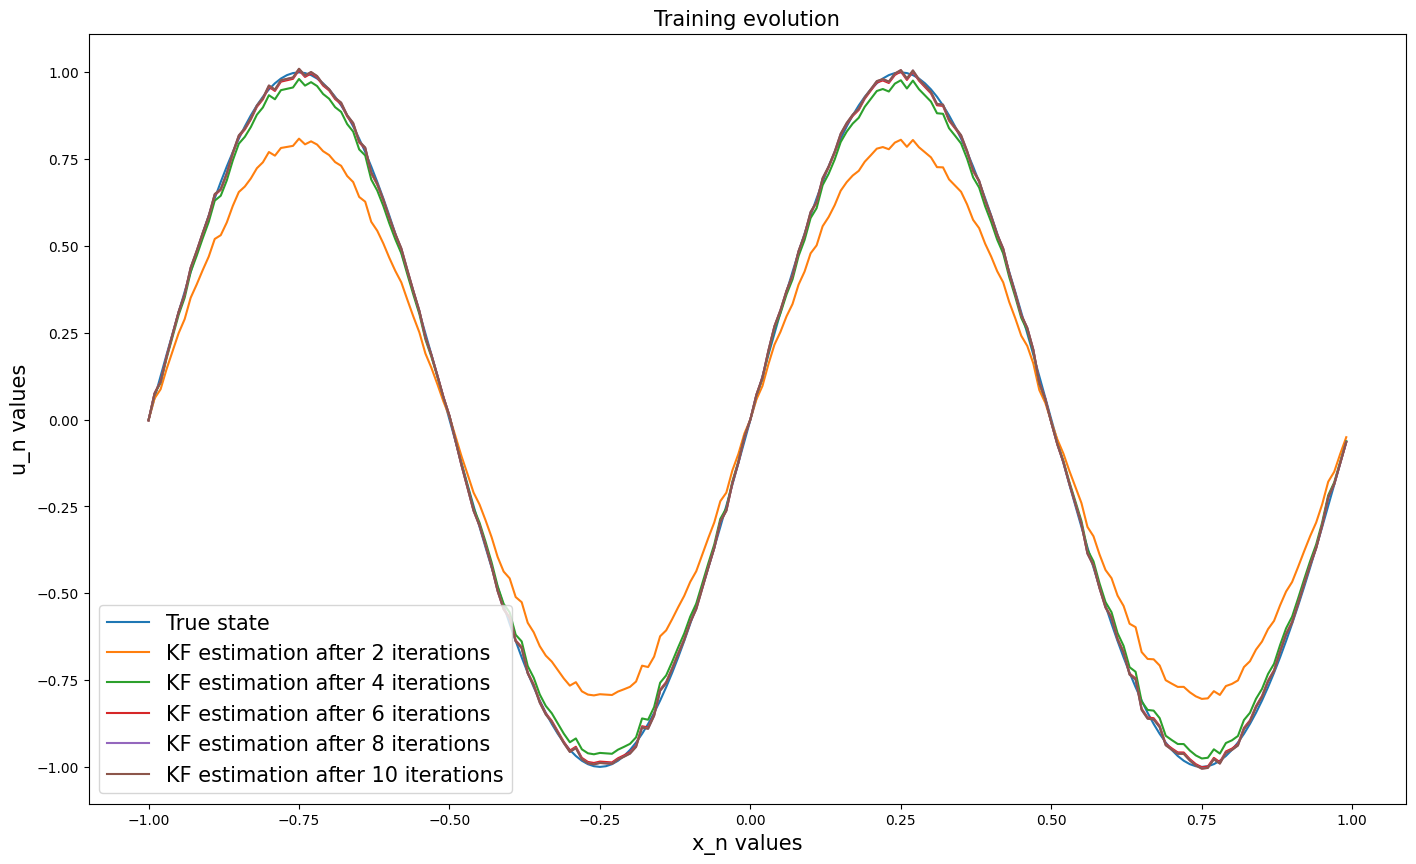

In [36]:

H = jnp.eye(n)
R = jnp.eye(n) * 0.005
Q = jnp.eye(n) * 0.005

P_0 = jnp.ones(A.shape)

key = jrandom.PRNGKey(int(time()))
w_k = jrandom.normal(key, shape=(x_0.shape[0], 1)) * 0.001
key = jrandom.PRNGKey(int(time()))
Z = jrandom.normal(key, shape=(x_0.shape[0], 1)) * 0.01
kf = KalmanFilter(jnp.zeros_like(x_0), A, B, H, H, R, Q, Z, w_k, P_0)

plot(kf, Z, iterations=10, plot_each=2)